# Timing test: Pareto comparison

Fig. 1 layout (test R² and the complexity–MSE Pareto frontier) for the current setup and each timing variant. Every number is computed here from saved predictions and PySR equation tables, using the same loaders and equation evaluator as the timing scripts.

In [2]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import proplot as pplt
sys.path.insert(0,os.path.abspath('.'))
from timingutils import TimingConfig,load_dataset,load_stats,restrict_kernel_seeds,calc_r2
from data import load_split,load_features
from equations import evaluate,raw_to_precip
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [3]:
VARIANTS  = ['current','concurrent']
SPLIT     = 'test'
R2REFS    = [0.25,0.5]
CONFIG    = TimingConfig()
NNRUNS    = CONFIG.nn['runs']
SRRUNS    = CONFIG.srruns
EQUATIONS = CONFIG.sr['optimizedeqs']
MODELINFO = {**{name:dict(label=run['description'],color=run['color'],marker='D') for name,run in NNRUNS.items()},
             **{name:dict(label=eq['description'],color=eq['color'],marker='o') for name,eq in EQUATIONS.items()}}
SAVEPATH  = os.path.join(CONFIG.resultsdir,'pareto.jpg')

In [4]:
def calc_scores(truth,grids):
    scores = [(calc_r2(truth,grid),float(np.nanmean(np.where(np.isfinite(grid),(grid-truth)**2,np.nan)))) for grid in grids]
    return tuple(np.mean(scores,axis=0))

def count_nn_params(run,nsigs):
    nfieldvars = len(run['fieldvars'])
    nlocalvars = len(run.get('localvars',[]))
    ninputs    = nfieldvars*nsigs+nlocalvars if run['kind']=='baseline' else nfieldvars+nlocalvars
    nkernel    = {'baseline':0,'nonparametric':nfieldvars*nsigs,'parametric':2*nfieldvars}[run['kind']]
    return nkernel+ninputs*256+256+256*128+128+128*64+64+64*32+32+32+1

def count_eq_params(name):
    nparams = EQUATIONS[name].get('complexity',EQUATIONS[name]['refcomplexity'])
    if nparams is not None and 'sr_atm_eq' in EQUATIONS[name]['form']:
        nparams += EQUATIONS['sr_atm_eq']['refcomplexity']
    return nparams

def load_grids(config,name):
    path = os.path.join(config.predsdir,f'{name}_{SPLIT}_predictions.nc')
    if not os.path.exists(path):
        return None
    pred = load_dataset(path)['tp']
    if 'complexity' in pred.dims:
        pred = pred.isel(complexity=0)
    pred = pred.transpose('time','lat','lon',...)
    return [pred.isel(seed=i).values for i in range(pred.sizes['seed'])] if 'seed' in pred.dims else [pred.values]

def calc_frontier(candidates):
    front,best = [],np.inf
    for candidate in sorted(candidates,key=lambda c:c['mse']):
        if candidate['nparams']<best:
            front.append(candidate)
            best = candidate['nparams']
    return sorted(front,key=lambda c:c['nparams'])

In [5]:
summaries = {}
for variant in VARIANTS:
    config = TimingConfig(None if variant=='current' else variant)
    restrict_kernel_seeds(config)
    stats  = load_stats(config)
    split  = load_split(config,SPLIT)
    truth  = split['tp'].transpose('time','lat','lon').values
    nsigs  = split.sizes['sig']
    results = {}
    for name in MODELINFO:
        grids = load_grids(config,name)
        if grids is None:
            continue
        r2,mse  = calc_scores(truth,grids)
        nparams = count_nn_params(NNRUNS[name],nsigs) if name in NNRUNS else count_eq_params(name)
        results[name] = dict(r2=r2,mse=mse,nparams=nparams)
    candidates = [dict(mse=r['mse'],nparams=r['nparams']) for r in results.values() if r['nparams'] is not None]
    for run,runconfig in SRRUNS.items():
        csvpaths = [os.path.join(config.modelsdir,'sr',f'{run}_{seed}_equations.csv') for seed in config.sr['seeds']]
        csvpaths = [path for path in csvpaths if os.path.exists(path)]
        if not csvpaths or (runconfig.get('residualfrom') and not os.path.exists(os.path.join(config.modelsdir,'sr','optimized_equations.csv'))):
            continue
        x,_,_,valid = load_features(config,SPLIT,runconfig)
        columns = {c:x[c].values for c in x.columns if c!='timeidx'}
        offset  = EQUATIONS[runconfig['residualfrom']]['refcomplexity'] if runconfig.get('residualfrom') else 0
        rows    = []
        for path in csvpaths:
            for _,row in pd.read_csv(path).iterrows():
                pred = raw_to_precip(evaluate(str(row['equation']),columns,{}),stats)
                pred[~valid] = np.nan
                rows.append(dict(complexity=int(row['complexity']),mse=float(np.nanmean((pred-truth.ravel())**2))))
        for complexity,mse in pd.DataFrame(rows).groupby('complexity')['mse'].mean().items():
            candidates.append(dict(mse=mse,nparams=int(complexity)+offset))
    truthvar = float(np.nanvar(truth))
    summaries[variant] = dict(results=results,front=calc_frontier(candidates),mserefs={r2:(1-r2)*truthvar for r2 in R2REFS})
    print(f'{variant}: {len(results)}/{len(MODELINFO)} models, {len(candidates)} frontier candidates')
pd.DataFrame({variant:{MODELINFO[name]['label']:round(r['r2'],3) for name,r in s['results'].items()} for variant,s in summaries.items()})

current: 9/10 models, 60 frontier candidates
concurrent: 6/10 models, 79 frontier candidates


,current,concurrent
NN-BL,0.286,0.275
NN-FULL,0.599,NaN
NN-NONPARAM,0.517,NaN
NN-GAUSS,0.522,0.501
SR-BL,0.293,0.275
SR-ATM,0.336,0.321
SR-SFC,0.397,0.386
SR-ALL,0.426,0.408
SR-ALL-PC,0.428,NaN


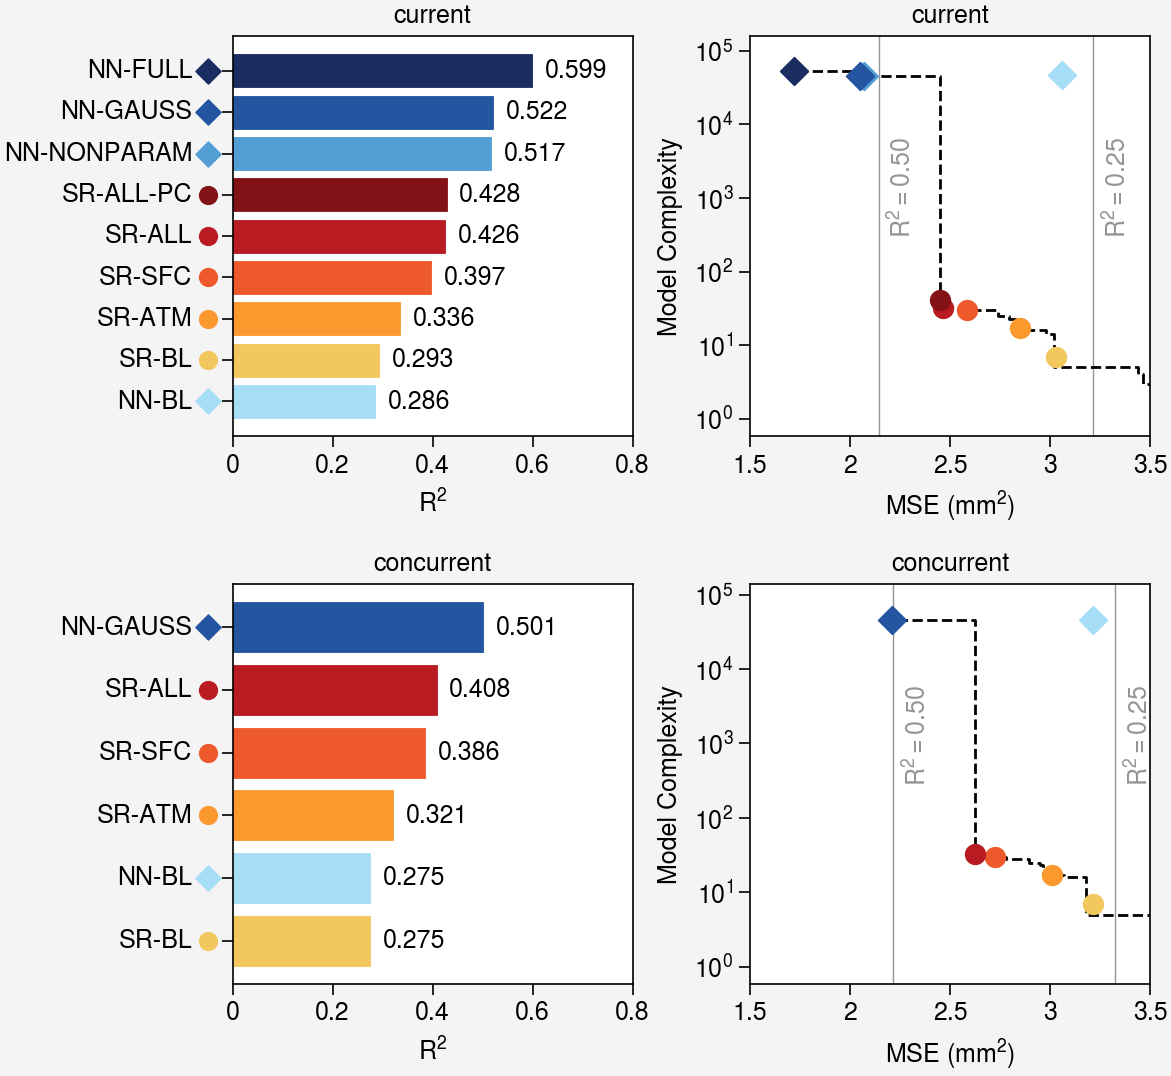

In [6]:
fig,axs = pplt.subplots(nrows=len(VARIANTS),ncols=2,refwidth=2,refheight=2,share=False,wspace=4.7)
for row,(variant,s) in enumerate(summaries.items()):
    rows = sorted(s['results'].items(),key=lambda item:item[1]['r2'])
    ax   = axs[row,0]
    ax.barh(range(len(rows)),[r['r2'] for _,r in rows],color=[MODELINFO[name]['color'] for name,_ in rows])
    ax.set_yticks(range(len(rows)))
    ax.set_yticklabels([])
    for i,(name,r) in enumerate(rows):
        ax.scatter(-0.05,i,marker=MODELINFO[name]['marker'],color=MODELINFO[name]['color'],markersize=40,clip_on=False)
        ax.text(-0.08,i,MODELINFO[name]['label'],va='center',ha='right')
        ax.text(max(r['r2']+0.15,0.01),i,f"{r['r2']:.3f}",va='center',ha='right')
    ax.format(grid=False,xlabel=r'$R^2$',xlim=(0,0.8),title=variant)
    ax = axs[row,1]
    ax.plot([c['mse'] for c in s['front']],[c['nparams'] for c in s['front']],color='k',linestyle='--',linewidth=1,zorder=3,drawstyle='steps-pre')
    for name,r in s['results'].items():
        if r['nparams'] is not None:
            ax.scatter(r['mse'],r['nparams'],color=MODELINFO[name]['color'],marker=MODELINFO[name]['marker'],markersize=50,zorder=6)
    for r2,mse in s['mserefs'].items():
        ax.axvline(mse,color='gray',linewidth=0.5)
        ax.text(mse+0.05,0.75,rf'$R^2={r2:.2f}$',color='gray',rotation=90,va='top',ha='left',transform=ax.get_xaxis_transform())
    ymax = 3*max(r['nparams'] for r in s['results'].values() if r['nparams'] is not None)
    ax.format(grid=False,xlabel=r'MSE (mm$^2$)',xlim=(1.5,3.5),ylim=(None,ymax),yscale='log',yformatter='log',ylabel='Model Complexity',title=variant)
pplt.show()
fig.save(SAVEPATH)